# Fingerprints: Converting Molecules to Numbers

Based on the MoleculeNet paper (Wu et al., 2018) and the RDKit documentation,
molecular fingerprints are the standard way to convert chemical structures
into numerical vectors for machine learning.

Morgan Fingerprints specifically work by looking at circular neighborhoods
around each atom at a given radius. Each unique pattern found gets assigned
to a bit position in a fixed-length binary array.

Sources:
- Wu et al., MoleculeNet (2018): https://pmc.ncbi.nlm.nih.gov/articles/PMC5868307/
- Generating Molecular Fingerprints using RDKit: https://www.youtube.com/watch?v=4jRBRDbJemM

 strings encode the molecular structure of each compound.

In [1]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

print("imports done")

imports done


In [2]:
# Ethanol 
smiles = "CCO"
mol = Chem.MolFromSmiles(smiles)
print(mol)

generate fingerprint

convert molecule object into 2048 bit binary array.
Morgan generator works at radius 2 that means lokks 2 bonds away from each atom to detect structural patterns.


In [3]:
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fp = fp_gen.GetFingerprint(mol)

# Convert to a numpy array so we can work with it
arr = np.zeros((2048,))
from rdkit.Chem import DataStructs
DataStructs.ConvertToNumpyArray(fp, arr)

print("Fingerprint length:", len(arr))
print("Number of bits turned ON:", int(arr.sum()))
print("First 20 bits:", arr[:20])

Fingerprint length: 2048
Number of bits turned ON: 6
First 20 bits: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]



so the output explains that :
length 2048 that means every molecule gets same lenght array regardless of its size and allows comparision

for specifically ethanol as its very small molecule only 6 buts are turned on and they are scattered across all positions and all first 20 bits are zero 

now lets do the comparison 

In [4]:
molecules = {
    "Ethanol (simple)": "CCO",
    "Aspirin (medium)": "CC(=O)Oc1ccccc1C(=O)O",
    "Caffeine (complex)": "Cn1cnc2c1c(=O)n(c(=O)n2C)C"
}

for name, smiles in molecules.items():
    mol = Chem.MolFromSmiles(smiles)
    fp = fp_gen.GetFingerprint(mol)
    arr = np.zeros((2048,))
    DataStructs.ConvertToNumpyArray(fp, arr)
    print(f"{name}: {int(arr.sum())} bits ON")

Ethanol (simple): 6 bits ON
Aspirin (medium): 24 bits ON
Caffeine (complex): 25 bits ON


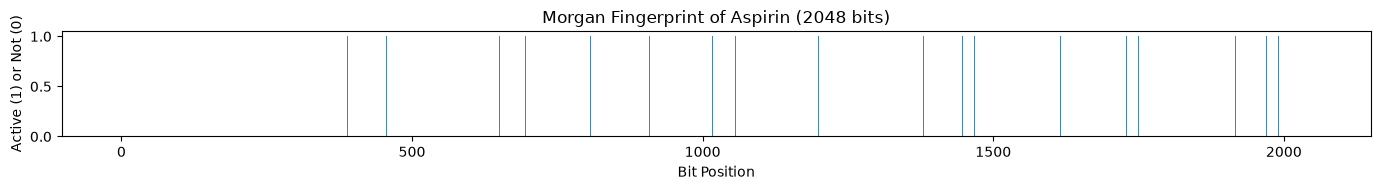

In [10]:
mol_aspirin = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
fp = fp_gen.GetFingerprint(mol_aspirin)
arr = np.zeros((2048,))
DataStructs.ConvertToNumpyArray(fp, arr)

plt.figure(figsize=(14, 2))
plt.bar(range(2048), arr, width=1, color='steelblue')
plt.title("Morgan Fingerprint of Aspirin (2048 bits)")
plt.xlabel("Bit Position")
plt.ylabel("Active (1) or Not (0)")
plt.tight_layout()
plt.show()

each sharp spike is an active bit 

In [9]:
import matplotlib.pyplot as plt